GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

Training CNN1
Epoch 1/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.1478 - loss: 2.2229 - val_accuracy: 0.3116 - val_loss: 1.8420
Epoch 2/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3314 - loss: 1.7835 - val_accuracy: 0.3767 - val_loss: 1.6763
Epoch 3/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3833 - loss: 1.6585 - val_accuracy: 0.4060 - val_loss: 1.5965
Epoch 4/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4106 - loss: 1.5890 - val_accuracy: 0.4211 - val_loss: 1.5496
Epoch 5/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4206 - loss: 1.5551 - val_accuracy: 0.4281 - val_loss: 1.5339
Epoch 6/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4311 - loss: 1.5260 - val_accuracy: 0.4362 - val_loss: 1.5040
Epoch 7/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4427 - loss: 1.5078 - val_accuracy: 0.4327 - val_loss: 1.5260
Epoch 8/8
391/391 ━━━━━

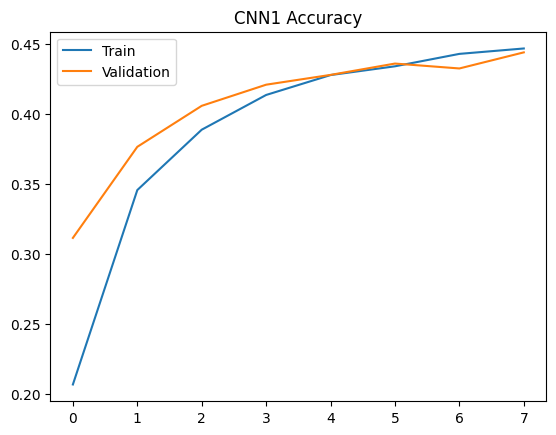

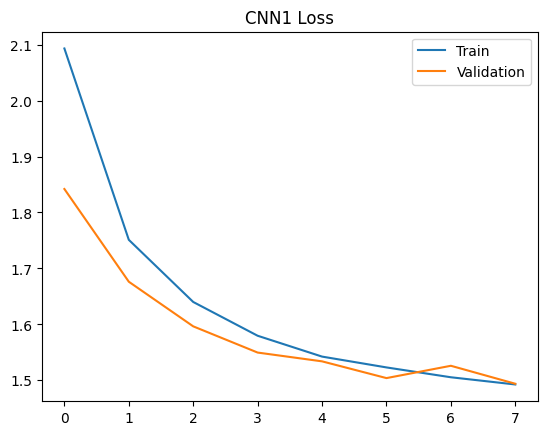

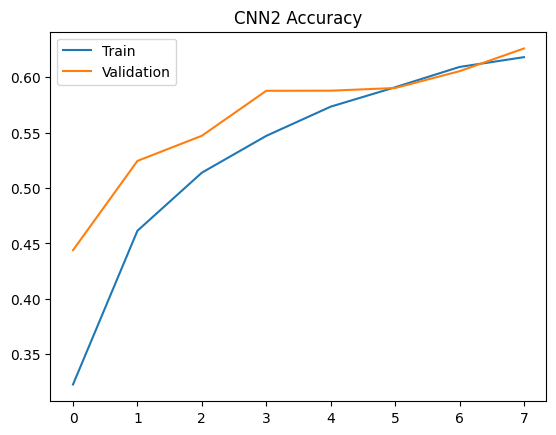

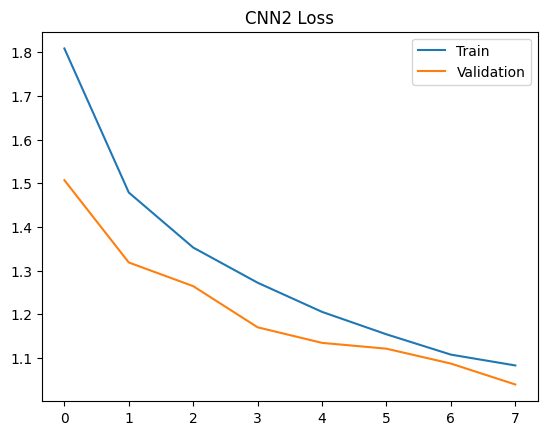

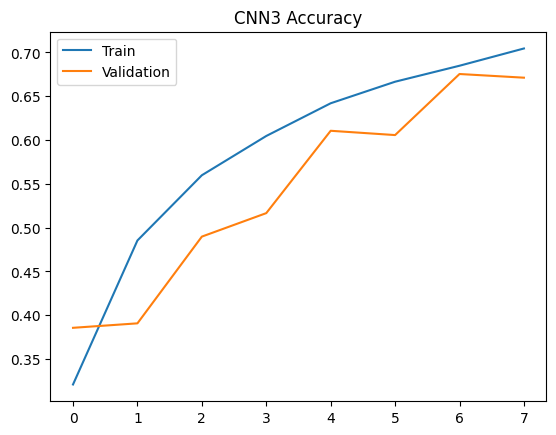

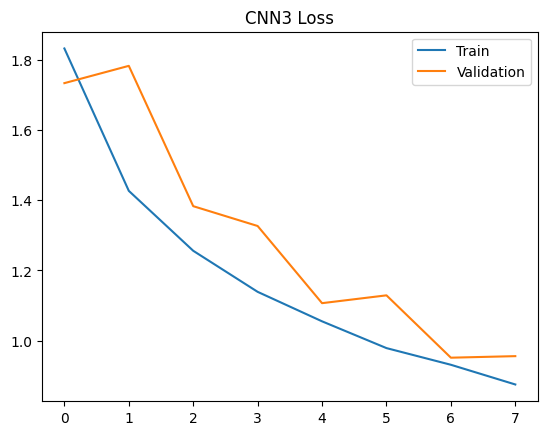

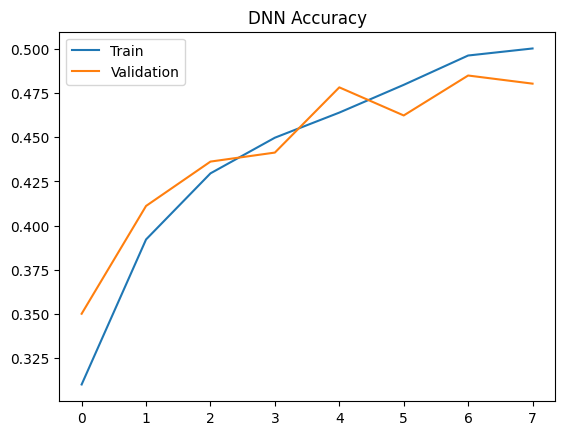

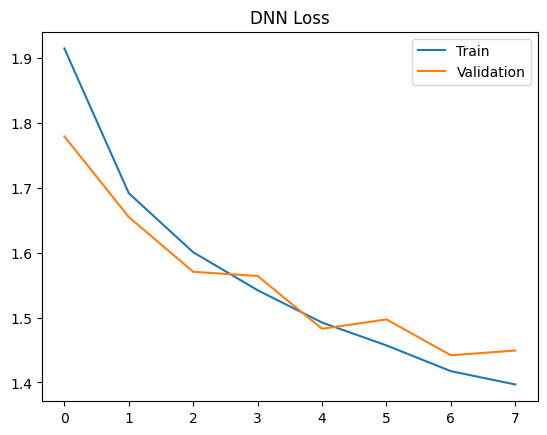

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import time



IMG_SIZE = 32
BATCH_SIZE = 128
EPOCHS = 8

print("GPU:", tf.config.list_physical_devices('GPU'))



(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

train_ds = (
    tf.data.Dataset.from_tensor_slices((x_train, y_train))
    .shuffle(10000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    tf.data.Dataset.from_tensor_slices((x_test, y_test))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)



# CNN MODEL 1
def build_cnn1():
    return models.Sequential([
        layers.Conv2D(8,(3,3),strides=1,padding='valid',
                      activation='relu',
                      input_shape=(IMG_SIZE,IMG_SIZE,3)),
        layers.MaxPooling2D(pool_size=(2,2),strides=2),

        layers.Conv2D(4,(3,3),activation='relu'),
        layers.MaxPooling2D(pool_size=(2,2),strides=2),

        layers.Flatten(),
        layers.Dense(8,activation='relu'),
        layers.Dense(10,activation='softmax')
    ])

# CNN MODEL 2
def build_cnn2():
    return models.Sequential([
        layers.Conv2D(16,(3,3),activation='relu',
                      input_shape=(IMG_SIZE,IMG_SIZE,3)),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(32,(3,3),activation='relu'),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64,(3,3),activation='relu'),
        layers.MaxPooling2D((2,2)),

        layers.Flatten(),
        layers.Dense(128,activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10,activation='softmax')
    ])

# CNN MODEL 3
def build_cnn3():
    return models.Sequential([
        layers.Conv2D(32,(5,5),strides=1,activation=None,
                      input_shape=(IMG_SIZE,IMG_SIZE,3)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64,(3,3),activation=None),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(128,(3,3),activation='relu'),
        layers.MaxPooling2D((2,2)),

        layers.Flatten(),
        layers.Dense(256,activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(64,activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10,activation='softmax')
    ])

# DNN MODEL
def build_dnn():
    return models.Sequential([
        layers.Flatten(input_shape=(IMG_SIZE,IMG_SIZE,3)),
        layers.Dense(512,activation='relu'),
        layers.Dense(256,activation='relu'),
        layers.Dense(128,activation='relu'),
        layers.Dense(10,activation='softmax')
    ])



results = {}

def train_model(model,name):

    print(f"\nTraining {name}")
    start = time.time()

    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(train_ds,
                        epochs=EPOCHS,
                        validation_data=test_ds,
                        verbose=1)

    end = time.time()

    results[name] = {
        "history": history,
        "train_acc": history.history['accuracy'][-1],
        "test_acc": history.history['val_accuracy'][-1],
        "params": model.count_params(),
        "time": end-start
    }



train_model(build_cnn1(),"CNN1")
train_model(build_cnn2(),"CNN2")
train_model(build_cnn3(),"CNN3")
train_model(build_dnn(),"DNN")


print("\n===== MODEL COMPARISON =====")

for name,data in results.items():
    print(f"\n{name}")
    print("Training Accuracy:", round(data["train_acc"],4))
    print("Testing Accuracy :", round(data["test_acc"],4))
    print("Parameters       :", data["params"])
    print("Training Time(s) :", round(data["time"],2))



for name,data in results.items():

    h = data["history"]

    plt.figure()
    plt.plot(h.history['accuracy'])
    plt.plot(h.history['val_accuracy'])
    plt.title(name + " Accuracy")
    plt.legend(['Train','Validation'])
    plt.show()

    plt.figure()
    plt.plot(h.history['loss'])
    plt.plot(h.history['val_loss'])
    plt.title(name + " Loss")
    plt.legend(['Train','Validation'])
    plt.show()